In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [3]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"
MODELS_DIR = PROJECT_ROOT / "models"

DATA_LATENT.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X = np.load(DATA_PROCESSED / "X_windows.npy")
sample_dates = np.load(DATA_PROCESSED / "sample_dates.npy", allow_pickle=True)
sample_tickers = np.load(DATA_PROCESSED / "sample_tickers.npy", allow_pickle=True)

returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
returns.index = pd.to_datetime(returns.index)

sample_dates = pd.to_datetime(sample_dates)

X.shape

(70080, 60, 6)

In [4]:
HORIZON = 10

def make_future_returns(returns, horizon):
    future = pd.DataFrame(
        0.0,
        index=returns.index,
        columns=returns.columns
    )

    for h in range(1, horizon + 1):
        future += returns.shift(-h)

    return future

future_returns = make_future_returns(returns, HORIZON)

In [5]:
y_list = []

for date, ticker in zip(sample_dates, sample_tickers):
    try:
        y_list.append(future_returns.loc[date, ticker])
    except KeyError:
        y_list.append(np.nan)

y = np.array(y_list, dtype=np.float32)

mask = ~np.isnan(y)

X = X[mask]
y = y[mask]
sample_dates = sample_dates[mask]
sample_tickers = sample_tickers[mask]

X.shape, y.shape

((69780, 60, 6), (69780,))

In [6]:
# original: (n_samples, window, n_features)
# Conv1D:   (n_samples, n_features, window)

X_cnn = np.transpose(X, (0, 2, 1)).astype(np.float32)

X_cnn.shape

(69780, 6, 60)

In [7]:
y_mean = y.mean()
y_std = y.std()

y_scaled = ((y - y_mean) / (y_std + 1e-8)).astype(np.float32)

y_scaled.mean(), y_scaled.std()

(np.float32(8.746798e-10), np.float32(0.9999998))

In [8]:
dates_sorted = np.sort(pd.Series(sample_dates).unique())

train_ratio = 0.8
split_date = dates_sorted[int(train_ratio * len(dates_sorted))]

split_date

np.datetime64('2023-02-09T00:00:00.000000000')

In [9]:
train_mask = sample_dates < split_date
val_mask = sample_dates >= split_date

X_train = X_cnn[train_mask]
y_train = y_scaled[train_mask]

X_val = X_cnn[val_mask]
y_val = y_scaled[val_mask]

X_train.shape, X_val.shape

((55800, 6, 60), (13980, 6, 60))

In [10]:
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train).view(-1, 1)

X_val_tensor = torch.tensor(X_val)
y_val_tensor = torch.tensor(y_val).view(-1, 1)

train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=256,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=256,
    shuffle=False
)

In [11]:
class SupervisedCNNVAE(nn.Module):
    def __init__(self, n_features, window, latent_dim=8):
        super().__init__()

        self.n_features = n_features
        self.window = window
        self.latent_dim = latent_dim

        self.encoder_conv = nn.Sequential(
            nn.Conv1d(n_features, 16, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, n_features, window)
            encoded = self.encoder_conv(dummy)
            self.encoded_shape = encoded.shape[1:]
            self.encoded_dim = encoded.numel()

        self.fc_mu = nn.Linear(self.encoded_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.encoded_dim, latent_dim)

        self.fc_decode = nn.Linear(latent_dim, self.encoded_dim)

        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(
                64, 32,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                32, 16,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose1d(
                16, n_features,
                kernel_size=5,
                stride=2,
                padding=2,
                output_padding=1
            ),
        )

        self.predictor = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def encode(self, x):
        h = self.encoder_conv(x)
        h = h.view(h.size(0), -1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(z.size(0), *self.encoded_shape)

        x_recon = self.decoder_conv(h)

        return x_recon[:, :, :self.window]

    def predict(self, z):
        return self.predictor(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)

        x_recon = self.decode(z)
        y_pred = self.predict(z)

        return x_recon, y_pred, mu, logvar

In [12]:
def supervised_vae_loss(
    x,
    x_recon,
    y,
    y_pred,
    mu,
    logvar,
    beta=1e-3,
    gamma=1.0
):
    recon_loss = nn.functional.mse_loss(
        x_recon,
        x,
        reduction="mean"
    )

    pred_loss = nn.functional.mse_loss(
        y_pred,
        y,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1 + logvar - mu.pow(2) - logvar.exp(),
            dim=1
        )
    )

    total_loss = recon_loss + beta * kl_loss + gamma * pred_loss

    return total_loss, recon_loss, kl_loss, pred_loss

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [16]:
n_samples, n_features, window = X_cnn.shape

LATENT_DIM = 8
BETA = 1e-3
GAMMA = 0.1

model = SupervisedCNNVAE(
    n_features=n_features,
    window=window,
    latent_dim=LATENT_DIM
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [17]:
n_epochs = 100
patience = 10

best_val_corr = -np.inf
best_state = None
best_epoch = None
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_recon": [],
    "train_kl": [],
    "train_pred": [],
    "val_loss": [],
    "val_recon": [],
    "val_kl": [],
    "val_pred": [],
    "val_corr": [],
}

for epoch in range(n_epochs):
    model.train()

    train_loss = 0.0
    train_recon = 0.0
    train_kl = 0.0
    train_pred = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        x_recon, y_pred, mu, logvar = model(x_batch)

        loss, recon_loss, kl_loss, pred_loss = supervised_vae_loss(
            x_batch,
            x_recon,
            y_batch,
            y_pred,
            mu,
            logvar,
            beta=BETA,
            gamma=GAMMA
        )

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(x_batch)
        train_recon += recon_loss.item() * len(x_batch)
        train_kl += kl_loss.item() * len(x_batch)
        train_pred += pred_loss.item() * len(x_batch)

    train_loss /= len(X_train_tensor)
    train_recon /= len(X_train_tensor)
    train_kl /= len(X_train_tensor)
    train_pred /= len(X_train_tensor)

    model.eval()

    val_loss = 0.0
    val_recon = 0.0
    val_kl = 0.0
    val_pred = 0.0

    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            x_recon, y_pred, mu, logvar = model(x_batch)

            loss, recon_loss, kl_loss, pred_loss = supervised_vae_loss(
                x_batch,
                x_recon,
                y_batch,
                y_pred,
                mu,
                logvar,
                beta=BETA,
                gamma=GAMMA
            )

            val_loss += loss.item() * len(x_batch)
            val_recon += recon_loss.item() * len(x_batch)
            val_kl += kl_loss.item() * len(x_batch)
            val_pred += pred_loss.item() * len(x_batch)

            y_true_all.append(y_batch.cpu().numpy())
            y_pred_all.append(y_pred.cpu().numpy())

    val_loss /= len(X_val_tensor)
    val_recon /= len(X_val_tensor)
    val_kl /= len(X_val_tensor)
    val_pred /= len(X_val_tensor)

    y_true_all = np.concatenate(y_true_all).ravel()
    y_pred_all = np.concatenate(y_pred_all).ravel()

    val_corr = np.corrcoef(y_true_all, y_pred_all)[0, 1]

    history["train_loss"].append(train_loss)
    history["train_recon"].append(train_recon)
    history["train_kl"].append(train_kl)
    history["train_pred"].append(train_pred)

    history["val_loss"].append(val_loss)
    history["val_recon"].append(val_recon)
    history["val_kl"].append(val_kl)
    history["val_pred"].append(val_pred)
    history["val_corr"].append(val_corr)

    if val_corr > best_val_corr:
        best_val_corr = val_corr
        best_epoch = epoch
        best_state = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch % 5 == 0 or epoch == n_epochs - 1:
        print(
            f"Epoch {epoch:03d} | "
            f"train loss: {train_loss:.4f} | "
            f"val loss: {val_loss:.4f} | "
            f"val recon: {val_recon:.4f} | "
            f"val pred: {val_pred:.4f} | "
            f"val corr: {val_corr:.4f} | "
            f"best corr: {best_val_corr:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break

model.load_state_dict(best_state)

print("Best epoch:", best_epoch)
print("Best val corr:", best_val_corr)

Epoch 000 | train loss: 0.6455 | val loss: 0.4086 | val recon: 0.2961 | val pred: 0.9505 | val corr: 0.0960 | best corr: 0.0960
Epoch 005 | train loss: 0.3684 | val loss: 0.3488 | val recon: 0.2330 | val pred: 0.9697 | val corr: 0.0755 | best corr: 0.1006
Epoch 010 | train loss: 0.3591 | val loss: 0.3534 | val recon: 0.2313 | val pred: 1.0292 | val corr: 0.0441 | best corr: 0.1006
Early stopping at epoch 11
Best epoch: 1
Best val corr: 0.10059275426364513


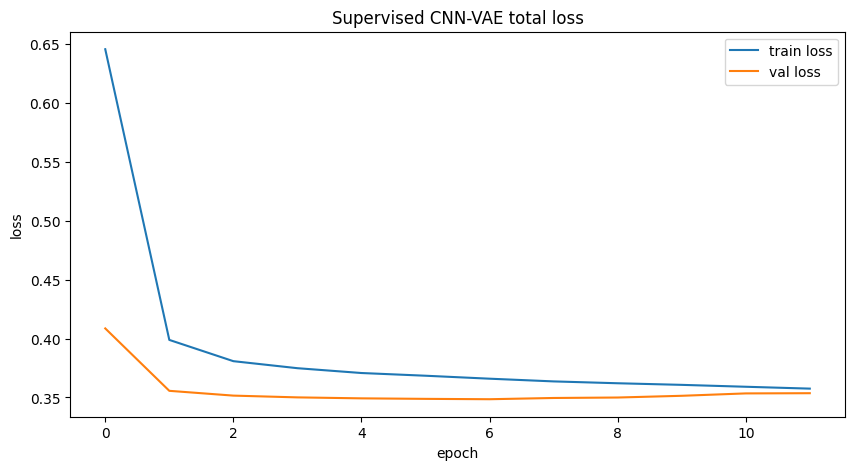

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_loss"], label="train loss")
plt.plot(history["val_loss"], label="val loss")

plt.title("Supervised CNN-VAE total loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

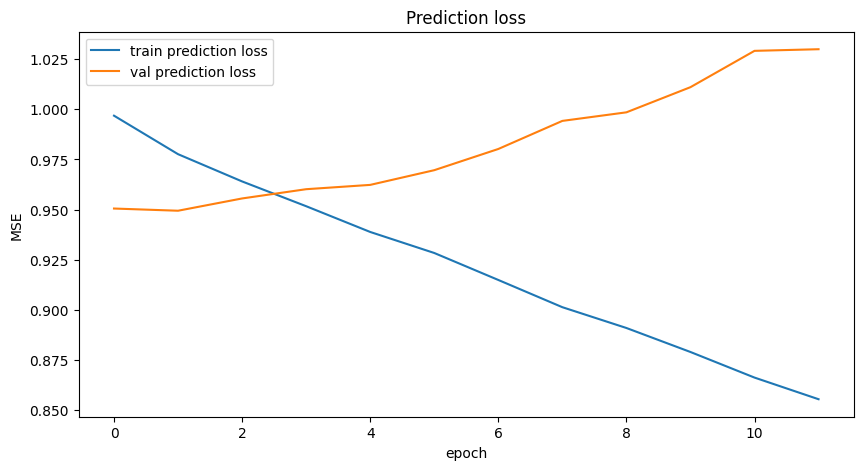

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_pred"], label="train prediction loss")
plt.plot(history["val_pred"], label="val prediction loss")

plt.title("Prediction loss")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

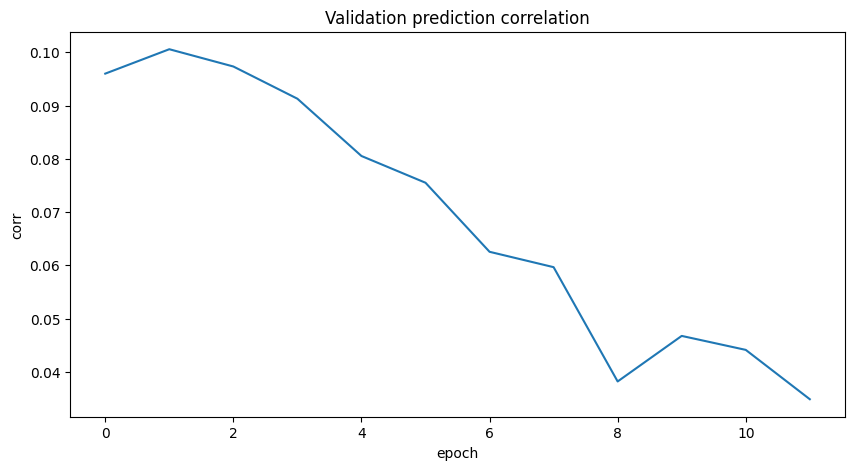

In [20]:
plt.figure(figsize=(10, 5))

plt.plot(history["val_corr"])

plt.title("Validation prediction correlation")
plt.xlabel("epoch")
plt.ylabel("corr")
plt.show()

In [21]:
all_tensor = torch.tensor(X_cnn)

all_loader = DataLoader(
    TensorDataset(all_tensor),
    batch_size=512,
    shuffle=False
)

Z_list = []
pred_list = []

model.eval()

with torch.no_grad():
    for batch in all_loader:
        x_batch = batch[0].to(device)

        mu, logvar = model.encode(x_batch)
        y_pred = model.predict(mu)

        Z_list.append(mu.cpu().numpy())
        pred_list.append(y_pred.cpu().numpy())

Z = np.concatenate(Z_list, axis=0)
pred_scaled = np.concatenate(pred_list, axis=0).ravel()

pred_unscaled = pred_scaled * y_std + y_mean

Z.shape, pred_unscaled.shape

((69780, 8), (69780,))

In [22]:
sup_latent_df = pd.DataFrame(
    Z,
    columns=[f"z_{i}" for i in range(Z.shape[1])]
)

sup_latent_df["date"] = sample_dates
sup_latent_df["ticker"] = sample_tickers
sup_latent_df["target_return_10d"] = y
sup_latent_df["pred_return_10d"] = pred_unscaled

sup_latent_df = sup_latent_df[
    ["date", "ticker", "target_return_10d", "pred_return_10d"]
    + [f"z_{i}" for i in range(Z.shape[1])]
]

sup_latent_df.head()

,date,ticker,target_return_10d,pred_return_10d,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,-0.038254,0.017117,-0.165311,1.134504,-1.445229,1.191268,0.838135,1.248731,-0.626914,-0.358154
1,2015-09-22,AAPL,-0.017760,0.017041,-0.240465,1.112205,-1.361434,1.288137,0.763379,1.212089,-0.619133,-0.295517
2,2015-09-23,AAPL,-0.030634,0.016867,-0.232379,1.105707,-1.205404,1.429420,0.567163,1.272981,-0.573612,-0.353675
3,2015-09-24,AAPL,-0.048136,0.016492,-0.165983,1.043628,-1.174774,1.460648,0.689822,1.340265,-0.535046,-0.214705
4,2015-09-25,AAPL,-0.021688,0.015912,-0.153574,1.114064,-1.045284,1.551994,0.410720,1.297225,-0.525672,-0.213376


In [23]:
sup_latent_df.to_parquet(
    DATA_LATENT / "supervised_cnn_vae_latents.parquet"
)

In [24]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "n_features": n_features,
        "window": window,
        "latent_dim": LATENT_DIM,
        "beta": BETA,
        "gamma": GAMMA,
        "horizon": HORIZON,
        "y_mean": y_mean,
        "y_std": y_std,
        "history": history,
    },
    MODELS_DIR / "supervised_cnn_vae.pt"
)